# Statistical Analysis

This notebook uses Python to investigate relationships between sales, profit, discounts, shipping costs and returns.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("../Data/commercial_returns.db")

In [3]:
analysis_df = pd.read_sql_query("""
SELECT
    o."Order ID",
    o.Sales,
    o.Profit,
    o.Discount,
    o."Shipping Cost",
    o.Quantity,
    CASE
        WHEN r."Order ID" IS NOT NULL THEN 1
        ELSE 0
    END AS returned
FROM orders o
LEFT JOIN returns r
ON o."Order ID" = r."Order ID";
""", conn)

analysis_df.head()

,Order ID,Sales,Profit,Discount,Shipping Cost,Quantity,returned
0,IN-2017-CA120551-42816,731.82,102.42,0.0,39.66,2,1
1,ID-2015-BD116051-42248,243.54,104.49,0.0,18.72,9,0
2,IN-2017-CA120551-42816,346.32,13.77,0.0,14.10,3,1
3,IN-2017-CA120551-42816,169.68,79.68,0.0,11.01,4,1
4,ID-2015-BD116051-42248,203.88,24.36,0.0,5.72,4,0


## Correlation Matrix

This section examines the relationships between key numeric variables including sales, profit, discount, shipping cost, quantity and return status.

In [4]:
correlation_matrix = analysis_df[
    ["Sales", "Profit", "Discount", "Shipping Cost", "Quantity", "returned"]
].corr()

correlation_matrix

,Sales,Profit,Discount,Shipping Cost,Quantity,returned
Sales,1.000000,0.478173,-0.086279,0.767655,0.313594,-0.005011
Profit,0.478173,1.000000,-0.316703,0.351920,0.103570,-0.010254
Discount,-0.086279,-0.316703,1.000000,-0.078126,-0.019861,0.024924
Shipping Cost,0.767655,0.351920,-0.078126,1.000000,0.272004,-0.001288
Quantity,0.313594,0.103570,-0.019861,0.272004,1.000000,-0.002481
returned,-0.005011,-0.010254,0.024924,-0.001288,-0.002481,1.000000


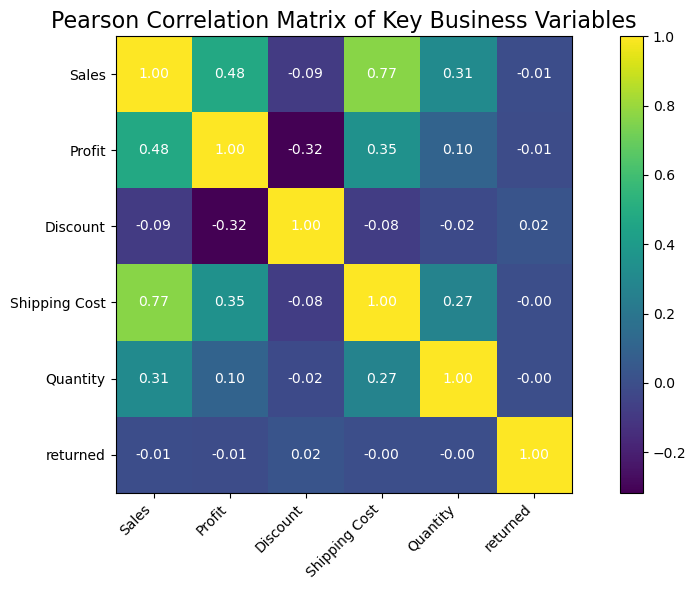

In [5]:
plt.figure(figsize=(10,6))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

# Add Pearson correlation values inside each square
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="white",
            fontsize=10
        )

plt.title("Pearson Correlation Matrix of Key Business Variables", fontsize=16)

plt.tight_layout()

plt.savefig("../Images/correlation_matrix.png", dpi=300)

plt.show()

## Discount vs Profit

This section investigates the relationship between discount levels and profitability using a scatter plot.

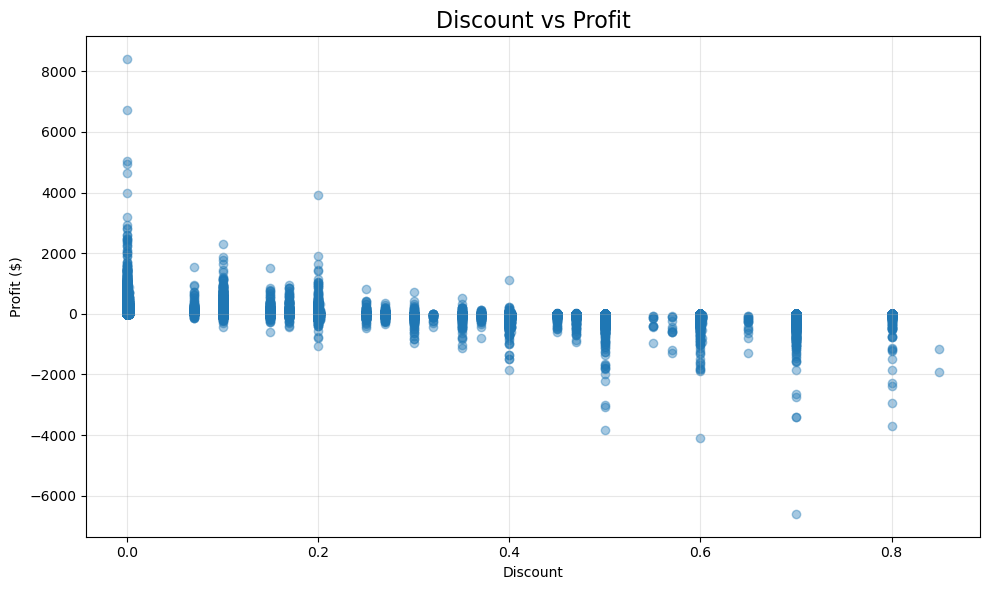

In [6]:
plt.figure(figsize=(10,6))

plt.scatter(
    analysis_df["Discount"],
    analysis_df["Profit"],
    alpha=0.4
)

plt.title("Discount vs Profit", fontsize=16)
plt.xlabel("Discount")
plt.ylabel("Profit ($)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../Images/discount_vs_profit.png", dpi=300)

plt.show()

## Profit Distribution by Return Status

This section compares the distribution of profit between returned and non-returned orders to determine whether returned orders are generally less profitable.

<Figure size 800x600 with 0 Axes>

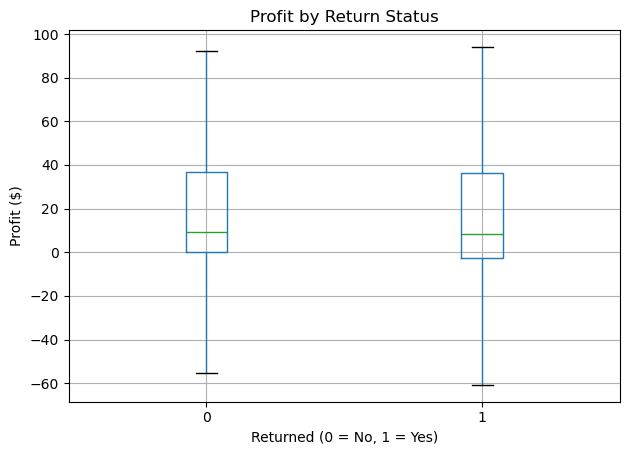

In [7]:
plt.figure(figsize=(8,6))

analysis_df.boxplot(
    column="Profit",
    by="returned",
    showfliers=False
)

plt.title("Profit by Return Status")
plt.suptitle("")
plt.xlabel("Returned (0 = No, 1 = Yes)")
plt.ylabel("Profit ($)")

plt.tight_layout()

plt.savefig("../Images/profit_by_return_status.png", dpi=300)

plt.show()

In [8]:
analysis_df.groupby("returned")["Profit"].describe()

,count,mean,std,min,25%,50%,75%,max
returned,,,,,,,,
0,45538.0,29.225268,176.590177,-6599.978,0.0000,9.36,36.91275,8399.976
1,6055.0,23.650235,162.308025,-3399.980,-2.6595,8.16,36.22890,1906.485


## Independent Samples t-Test

This section tests whether the average profit differs significantly between returned and non-returned orders.

### Hypotheses

- **Null Hypothesis (H₀):** There is no significant difference in average profit between returned and non-returned orders.
- **Alternative Hypothesis (H₁):** There is a significant difference in average profit between returned and non-returned orders.

In [9]:
from scipy.stats import ttest_ind

In [10]:
returned_profit = analysis_df.loc[
    analysis_df["returned"] == 1,
    "Profit"
]

not_returned_profit = analysis_df.loc[
    analysis_df["returned"] == 0,
    "Profit"
]

In [11]:
t_statistic, p_value = ttest_ind(
    returned_profit,
    not_returned_profit,
    equal_var=False
)

print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.5f}")

T-statistic: -2.484
P-value: 0.01300


In [12]:
import numpy as np

mean_returned = returned_profit.mean()
mean_not_returned = not_returned_profit.mean()

std_returned = returned_profit.std()
std_not_returned = not_returned_profit.std()

n_returned = len(returned_profit)
n_not_returned = len(not_returned_profit)

pooled_std = np.sqrt(
    (
        ((n_returned - 1) * std_returned**2) +
        ((n_not_returned - 1) * std_not_returned**2)
    ) /
    (n_returned + n_not_returned - 2)
)

cohens_d = (mean_returned - mean_not_returned) / pooled_std

print(f"Cohen's d: {cohens_d:.3f}")

Cohen's d: -0.032


## Multiple Linear Regression

This section builds a multiple linear regression model to examine how sales, discount, shipping cost, quantity and return status collectively explain profit.

The model estimates the contribution of each predictor while controlling for the effects of the other variables.

In [13]:
import statsmodels.api as sm

In [14]:
X = analysis_df[
    ["Sales", "Discount", "Shipping Cost", "Quantity", "returned"]
]

y = analysis_df["Profit"]

In [15]:
X = sm.add_constant(X)

In [16]:
model = sm.OLS(y, X).fit()

In [17]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.308
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     4592.
Date:                Sun, 05 Jul 2026   Prob (F-statistic):               0.00
Time:                        13:17:36   Log-Likelihood:            -3.3017e+05
No. Observations:               51593   AIC:                         6.604e+05
Df Residuals:                   51587   BIC:                         6.604e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            33.1870      1.275     26.026

In [18]:
print(f"R²: {model.rsquared:.3f}")
print(f"Adjusted R²: {model.rsquared_adj:.3f}")
print(f"Condition Number: {model.condition_number:,.0f}")

R²: 0.308
Adjusted R²: 0.308
Condition Number: 2,636


## Multicollinearity Assessment (Variance Inflation Factor)

This section evaluates multicollinearity among the independent variables using the Variance Inflation Factor (VIF).

VIF measures how strongly each predictor is linearly related to the remaining predictors.

### Interpretation

- **VIF = 1** → No multicollinearity
- **VIF < 5** → Generally acceptable
- **VIF > 5** → Potential concern
- **VIF > 10** → Serious multicollinearity

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [20]:
vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif["VIF"] = vif["VIF"].round(2)

vif

,Variable,VIF
0,const,3.96
1,Sales,2.51
2,Discount,1.01
3,Shipping Cost,2.44
4,Quantity,1.11
5,returned,1.00
